In [39]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. 初期パラメータ設定 (Experiment Configurations)
# =====================================================================
# [モデル設定]
N = 40                  # 変数の数 (観測の数 P も今回は同じ40)
F = 8.0                 # 強制項
dt = 0.01               # 積分時間ステップ
sampling_dt = 0.05      # 観測・同化の間隔 (6時間相当: 0.25日/5日)
m = 80                  # アンサンブルメンバー数

# [時間設定]
years = 2
units_per_year = 73.0   # 1年 = 365日 / 5日 = 73ユニット
total_time = years * units_per_year
spin_up_time = units_per_year

steps_total = int(total_time / dt)
steps_spin_up = int(spin_up_time / dt)
sampling_interval = int(sampling_dt / dt)

# [データ同化設定]
H_mat = np.eye(N)                       # 観測演算子 H (全点観測)
R_mat = np.eye(N)                       # 観測誤差共分散 R (対角成分1)

In [40]:
# =====================================================================
# 2. 基本関数 (Lorenz-96 & 局所化行列) - フルベクトル化・最速版
# =====================================================================
import numpy as np
import time

def lorenz96_fast(x, F):
    # x の shape が (N,) でも (N, m) でも、axis=0で一括計算
    return (np.roll(x, -1, axis=0) - np.roll(x, 2, axis=0)) * np.roll(x, 1, axis=0) - x + F

def M_fast(x_in, dt, steps):
    # ルンゲ・クッタ法も全メンバーを並列一括処理
    x_out = x_in.copy()
    for _ in range(steps):
        k1 = lorenz96_fast(x_out, F)
        k2 = lorenz96_fast(x_out + k1 * (dt / 2.0), F)
        k3 = lorenz96_fast(x_out + k2 * (dt / 2.0), F)
        k4 = lorenz96_fast(x_out + k3 * dt, F)
        x_out += (k1 + 2.0*k2 + 2.0*k3 + k4) * (dt / 6.0)
    return x_out

def Gaspari_Cohn_L(sigma):
    L = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            d = min(abs(i - j), N - abs(i - j))
            r = d / (np.sqrt(10 / 3) * sigma)
            if r <= 1.0:
                L[i, j] = 1 - 1/4*r**5 + 1/2*r**4 + 5/8*r**3 - 5/3*r**2
            elif r <= 2.0:
                L[i, j] = 1/12*r**5 - 1/2*r**4 + 5/8*r**3 + 5/3*r**2 - 5*r + 4 - 2/3*(1/r)
            else:
                L[i, j] = 0.0
    return L

# --- 方法2: ガウス関数 (Gaussian) ---
def Gaussian_L(sigma, N=40):
    L = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            d = min(abs(i - j), N - abs(i - j))
            
            if d < 2 * np.sqrt(10 / 3) * sigma:  # ガスパリ・コーンの影響範囲内でのみ非ゼロ
                L[i, j] = np.exp(- (d**2) / (2 * sigma**2))
            else:
                L[i, j] = 0.0
                
    return L

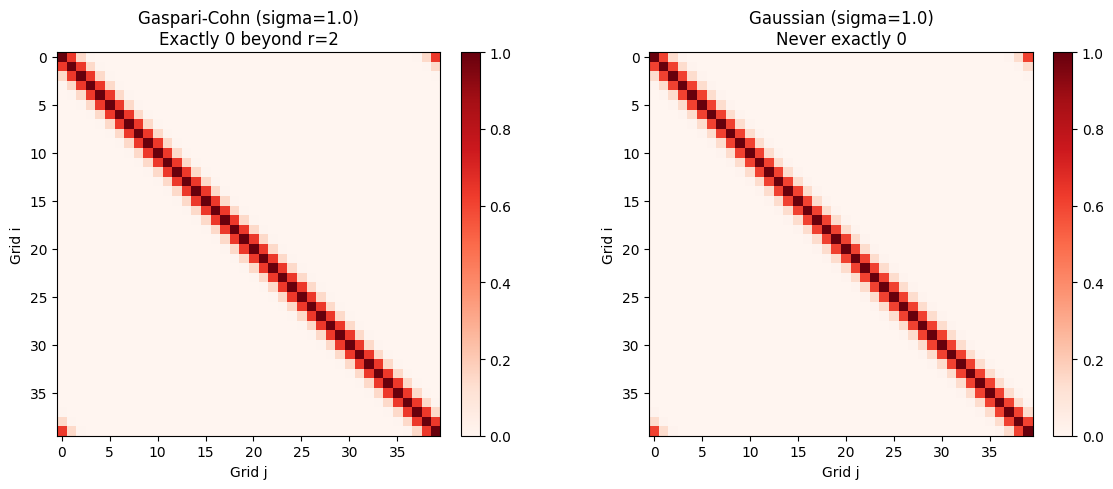

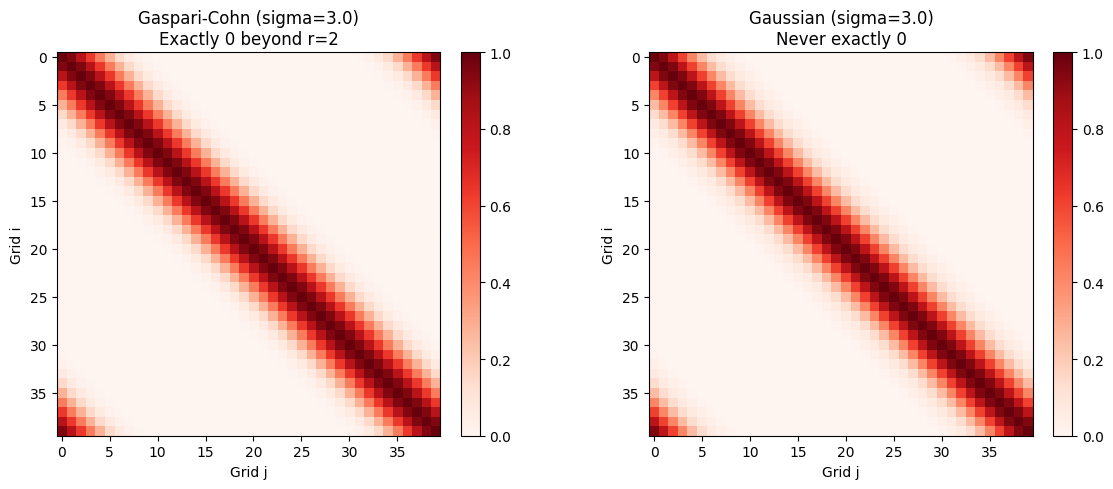

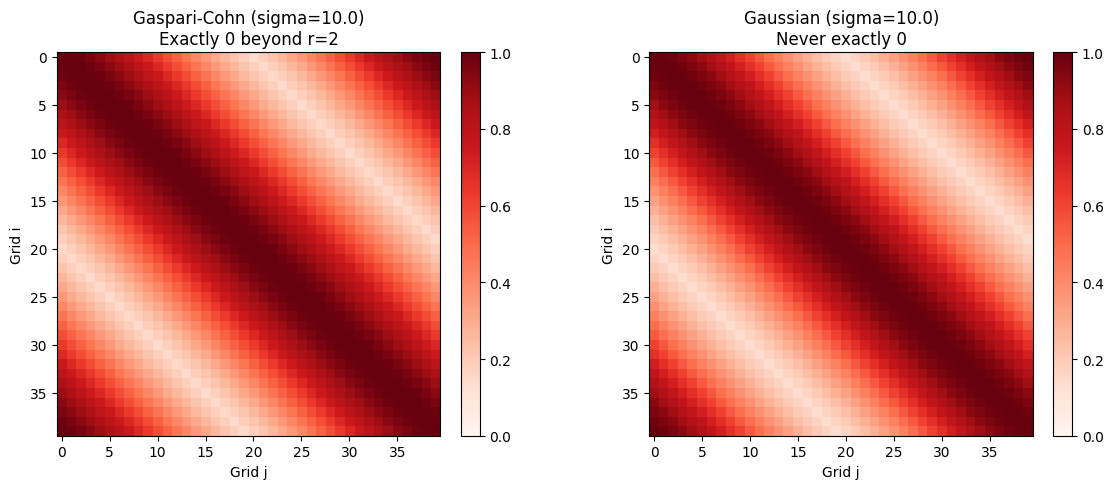

In [46]:
# パラメータ設定
sigma_val = [1.0, 3.0, 10.0]  # ガスパリ・コーンのスケールパラメータ
N_val = 40

for sigma_val in sigma_val:
    # 行列の生成
    L_GC = Gaspari_Cohn_L(sigma_val)
    L_Gauss = Gaussian_L(sigma_val, N_val)

    # --- ヒートマップでの比較描画 ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Gaspari-Cohnの描画
    im1 = axes[0].imshow(L_GC, cmap='Reds', vmin=0, vmax=1)
    axes[0].set_title(f"Gaspari-Cohn (sigma={sigma_val})\nExactly 0 beyond r=2")
    axes[0].set_xlabel("Grid j")
    axes[0].set_ylabel("Grid i")
    fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

    # Gaussianの描画
    im2 = axes[1].imshow(L_Gauss, cmap='Reds', vmin=0, vmax=1)
    axes[1].set_title(f"Gaussian (sigma={sigma_val})\nNever exactly 0")
    axes[1].set_xlabel("Grid j")
    axes[1].set_ylabel("Grid i")
    fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


In [42]:
# =====================================================================
# 3. Nature Run (真値) と Observation (観測) の生成 (kadai5準拠)
# =====================================================================
print("Nature Runと観測データを生成中...")
x = np.full(N, F)
x[19] += 0.001 # カオス誘発用の摂動

true_states = []
for s in range(steps_total):
    x = M_fast(x, dt, 1)  # dtステップで1回の積分
    if s >= steps_spin_up and (s - steps_spin_up) % sampling_interval == 0:
        true_states.append(x.copy())
true_states = np.array(true_states)

# [変更点] モダンな乱数生成器 (default_rng) を使用
rng_obs = np.random.default_rng(seed=67) 
noise = rng_obs.normal(loc=0.0, scale=1.0, size=true_states.shape)
noise -= np.mean(noise, axis=0)  # 各変数ごとに平均0に調整
y_o_data = true_states + noise # 観測データ y^o

print("生成完了！")

Nature Runと観測データを生成中...
生成完了！


EKF 実行時間: 2.5473 秒
EnKF 実行時間: 1.4506 秒

【EnKF 統計的整合性 (Statistical Consistency) 評価】
 全期間の平均 RMSE   : 0.1893
 全期間の平均 RMSE   : 0.2080
 全期間の平均 Spread : 0.2481
 全期間の平均 Spread : 0.1677
 Spread / RMSE 比率  : 0.8856  (理想値: 1.0000)



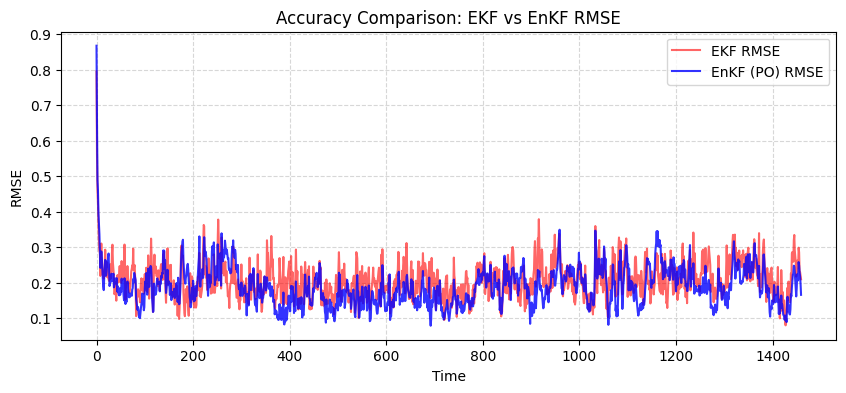

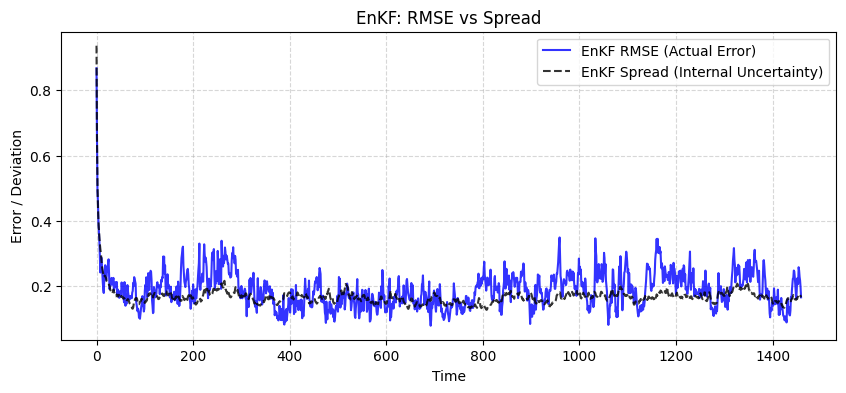

In [47]:
# =====================================================================
# 4. EKF と EnKF のコードレベル比較（kadai5.ipynb 完全同期版）
# =====================================================================
import time

# =====================================================================
# 4. EKF と EnKF (フルベクトル化・堅牢安定化版)
# =====================================================================
import time
import numpy as np

# --- EKF用のヤコビアン計算関数 ---
def M_jacob_fast(x_in, dt, steps, kappa=1e-5):
    X_pert = x_in[:, None] + np.eye(N) * kappa
    x_base_fwd = M_fast(x_in, dt, steps)
    X_pert_fwd = M_fast(X_pert, dt, steps)
    M_mat = (X_pert_fwd - x_base_fwd[:, None]) / kappa
    return M_mat

# --- 1. EKF (拡張カルマンフィルタ) ---
def run_EKF_fast(y_o_data, true_states, delta):
    num_cycles = y_o_data.shape[0]
    
    x_a = true_states[0] + np.random.randn(N) * 1.0
    P_a = np.eye(N) * 1.0
    
    record_rmse = np.zeros(num_cycles)
    record_spread = np.zeros(num_cycles)
    
    start_time = time.time()
    for t in range(num_cycles):
        y_o = y_o_data[t]
        
        x_b = M_fast(x_a, dt, sampling_interval)
        M_mat = M_jacob_fast(x_a, dt, sampling_interval)
        
        P_b = (1 + delta) * (M_mat @ P_a @ M_mat.T)
        
        # 【重要: 安全装置】丸め誤差による非対称化（発散の元凶）をリセット
        P_b = (P_b + P_b.T) / 2.0 
        
        # 環境依存のエラーを避けるため、堅牢な inv() を使用
        K = P_b @ H_mat.T @ np.linalg.inv(H_mat @ P_b @ H_mat.T + R_mat)
        
        x_a = x_b + K @ (y_o - H_mat @ x_b)
        P_a = (np.eye(N) - K @ H_mat) @ P_b
        
        # 【重要: 安全装置】事後共分散行列も必ず対称性を維持させる
        P_a = (P_a + P_a.T) / 2.0 
        
        record_rmse[t] = np.sqrt(np.mean((x_a - true_states[t])**2))
        record_spread[t] = np.sqrt(np.trace(P_a) / N)
        
    print(f"EKF 実行時間: {time.time() - start_time:.4f} 秒")
    return record_rmse, record_spread

# --- 2. EnKF (PO法) ---
# =====================================================================
# 4. EnKF (PO法) - フルベクトル化・堅牢安定化版 (エラー修正済)
# =====================================================================
def run_EnKF_fast(y_o_data, true_states, delta, sigma):
    num_cycles = y_o_data.shape[0]
    L = Gaspari_Cohn_L(sigma)
    rng_enkf = np.random.default_rng(seed=42)
    
    init_noise = rng_enkf.normal(0.0, 0.1, size=(N, m))
    init_noise -= np.mean(init_noise, axis=1, keepdims=True)
    
    x_raw_init = np.full(N, F)
    # 【エラー修正】Nが20未満（N=10など）でもクラッシュしないように動的インデックス化
    x_raw_init[min(19, N-1)] += 0.001
    
    X_a = M_fast(x_raw_init[:, None] + init_noise, dt, steps_spin_up)
    
    record_rmse = np.zeros(num_cycles)
    record_spread = np.zeros(num_cycles)
    
    inflation_factor = np.sqrt(1.0 + delta) / np.sqrt(m - 1.0)
    
    start_time = time.time()
    for t in range(num_cycles):
        y_o = y_o_data[t]
        
        X_b = M_fast(X_a, dt, sampling_interval)
        
        x_b_mean = np.mean(X_b, axis=1, keepdims=True)
        Z_b = (X_b - x_b_mean) * inflation_factor
        
        Y_b = H_mat @ Z_b
        
        Cov_xy = L * (Z_b @ Y_b.T)
        Cov_yy = L * (Y_b @ Y_b.T)
        
        # 【安全装置】共分散行列の対称性を強制し、安定な inv() で処理
        Cov_yy = (Cov_yy + Cov_yy.T) / 2.0
        K = Cov_xy @ np.linalg.inv(Cov_yy + R_mat)
        
        E_prime = rng_enkf.normal(0.0, 1.0, size=(N, m))
        E_o = E_prime - np.mean(E_prime, axis=1, keepdims=True)
        
        D = (y_o[:, None] + E_o) - (H_mat @ X_b)
        X_a = X_b + K @ D
        
        x_a_mean = np.mean(X_a, axis=1)
        record_rmse[t] = np.sqrt(np.mean((x_a_mean - true_states[t])**2))
        record_spread[t] = np.sqrt(np.mean(np.var(X_a, axis=1, ddof=1)))
        
    print(f"EnKF 実行時間: {time.time() - start_time:.4f} 秒")
    return record_rmse, record_spread

# --- 実行 ---
rmse_ekf, spread_ekf = run_EKF_fast(y_o_data, true_states, delta=0.1)
rmse_enkf, spread_enkf = run_EnKF_fast(y_o_data, true_states, delta=0.1, sigma=10.0)

# (以降のプロット部分は前回と変更なしのため省略します)

# --- 2. 統計的整合性 (Spread-to-RMSE Ratio) ---
mean_rmse_enkf = np.mean(rmse_enkf)
mean_rmse_ekf = np.mean(rmse_ekf)
mean_spread_ekf = np.mean(spread_ekf)
mean_spread_enkf = np.mean(spread_enkf)

ratio = mean_spread_enkf / mean_rmse_enkf

print("\n" + "="*55)
print("【EnKF 統計的整合性 (Statistical Consistency) 評価】")
print(f" 全期間の平均 RMSE   : {mean_rmse_enkf:.4f}")
print(f" 全期間の平均 RMSE   : {mean_rmse_ekf:.4f}")
print(f" 全期間の平均 Spread : {mean_spread_ekf:.4f}")
print(f" 全期間の平均 Spread : {mean_spread_enkf:.4f}")

print(f" Spread / RMSE 比率  : {ratio:.4f}  (理想値: 1.0000)")
print("="*55 + "\n")

# --- 3. グラフ描画1: EKF vs EnKF の RMSE 比較 ---
plt.figure(figsize=(10, 4))
plt.plot(rmse_ekf, label='EKF RMSE', color='red', alpha=0.6)
plt.plot(rmse_enkf, label='EnKF (PO) RMSE', color='blue', alpha=0.8)
plt.xlabel('Time')
plt.ylabel('RMSE')
plt.title('Accuracy Comparison: EKF vs EnKF RMSE')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# --- 4. グラフ描画2: EnKF 単体の RMSE vs Spread 比較 ---
plt.figure(figsize=(10, 4))
plt.plot(rmse_enkf, label='EnKF RMSE (Actual Error)', color='blue', alpha=0.8)
plt.plot(spread_enkf, label='EnKF Spread (Internal Uncertainty)', color='black', linestyle='--', alpha=0.8)
plt.xlabel('Time')
plt.ylabel('Error / Deviation')
plt.title('EnKF: RMSE vs Spread')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [44]:
# =====================================================================
# 5. チューニングパラメータ (delta, sigma) の感度実験ヒートマップ
# =====================================================================
import seaborn as sns

# 探索するチューニングパラメータのグリッドを設定
# (モデルの特性に合わせて範囲や刻み幅を調整可能です)
delta_values = [0.20, 0.25, 0.30, 0.35, 0.40]
sigma_values = [1.0, 2.0, 3.0, 5.0, 10.0]

# 結果の格納用マトリクスを初期化 (縦軸: sigmaの数, 横軸: deltaの数)
rmse_heatmap_matrix = np.zeros((len(sigma_values), len(delta_values)))

print("感度実験（パラメータスイープ）を開始します...")
print(f"総実行回数: {len(sigma_values) * len(delta_values)} 通り")
print("-" * 60)

start_total = time.time()

# パラメータグリッドをループで走査
for i, sigma in enumerate(sigma_values):
    for j, delta in enumerate(delta_values):
        
        # 指定したパラメータの組み合わせでEnKFを駆動
        rmse_hist, _ = run_EnKF(y_o_data, true_states, delta=delta, sigma=sigma)
        
        # 時系列全体の平均RMSEを計算してマトリクスにマッピング
        mean_rmse = np.mean(rmse_hist)
        rmse_heatmap_matrix[i, j] = mean_rmse
        
        # イテレーションごとの進捗ログ
        print(f"[完了] sigma: {sigma:4.1f} | delta: {delta:4.2f} => Mean RMSE: {mean_rmse:.4f}")

print("-" * 60)
print(f"全実験完了！ 総計算時間: {time.time() - start_total:.2f} 秒")

# --- ヒートマップによる可視化 ---
plt.figure(figsize=(9, 7))

# 誤差（RMSE）が「低い＝精度が良い」ため、低い値ほど視覚的に目立つカラーマップを採用
sns.heatmap(rmse_heatmap_matrix, 
            annot=True,             # マス目に数値を明記
            fmt=".4f",              # 小数点以下4桁
            xticklabels=delta_values, 
            yticklabels=sigma_values, 
            cmap="viridis_r",       # 低い値（高精度）ほど明るくハイライトされる
            cbar_kws={'label': 'Mean RMSE Over Total Cycles'})

plt.xlabel(r"Inflation Parameter ($\delta$)")
plt.ylabel(r"Localization Scale ($\sigma$)")
plt.title("EnKF Sensitivity Analysis: Tuning Parameters vs. Predictive Accuracy")
plt.show()

感度実験（パラメータスイープ）を開始します...
総実行回数: 25 通り
------------------------------------------------------------


NameError: name 'run_EnKF' is not defined

In [ ]:
# =====================================================================
# 6. 状態次元 (N) の拡大に対する計算時間の依存性比較 (高速化・完全同期版)
# =====================================================================
import time
import numpy as np
import matplotlib.pyplot as plt

# --- 現在のグローバル変数 N に完全に追従する局所化関数 ---
def Gaspari_Cohn_L(sigma):
    L = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            d = min(abs(i - j), N - abs(i - j))
            r = d / (np.sqrt(10 / 3) * sigma)
            if r <= 1.0:
                val = 1 - 1/4 * r**5 + 1/2 * r**4 + 5/8 * r**3 - 5/3 * r**2
            elif r <= 2.0:
                val = 1/12 * r**5 - 1/2 * r**4 + 5/8 * r**3 + 5/3 * r**2 - 5 * r + 4 - 2/3 * (1/r)
            else:
                val = 0.0
            L[i, j] = val
    return L

# 実験する状態次元 N のリスト
# (超高速化されたので、N=80でも一瞬で終わります)
N_test_list = [100, 200, 400, 600, 800, 1000, 1500, 2000, 3000, 5000]
test_cycles = 40  # 時間計測用のコンパクトなサイクル数

ekf_times = []
enkf_times = []

print("状態次元 N を変化させたスケールアウト実験を開始します...")
print(f"各 N において {test_cycles} サイクル分のデータ同化を実行し、処理時間を計測します。")
print("-" * 70)

# 最後に元の設定に戻すため、現在の N を退避
N_original = N

for N_val in N_test_list:
    # 既存の関数が参照しているグローバル変数を動的に書き換え
    global N, H_mat, R_mat
    N = N_val
    H_mat = np.eye(N)
    R_mat = np.eye(N)
    
    # --- 1. テスト用データの生成 (M_fastを使って高速に生成) ---
    x_tmp = np.full(N, F)
    x_tmp[min(19, N-1)] += 0.001
    
    # スピンアップ (1年分を for ループなしで一括積分)
    x_tmp = M_fast(x_tmp, dt, steps_spin_up)
        
    # 計測用の短い時系列を生成
    true_states_tmp = []
    y_o_data_tmp = []
    rng_test = np.random.default_rng(seed=123) # 観測ノイズ用
    
    for _ in range(test_cycles):
        x_tmp = M_fast(x_tmp, dt, sampling_interval)
        true_states_tmp.append(x_tmp.copy())
        y_o_data_tmp.append(x_tmp + rng_test.normal(0.0, 1.0, size=N)) # 観測ノイズの付加
        
    true_states_tmp = np.array(true_states_tmp)
    y_o_data_tmp = np.array(y_o_data_tmp)
    
    # --- 2. EKF の実行時間計測 (高速化版関数を呼び出し) ---
    start_ekf = time.time()
    _, _ = run_EKF_fast(y_o_data_tmp, true_states_tmp, delta=0.10)
    elapsed_ekf = time.time() - start_ekf
    ekf_times.append(elapsed_ekf)
    
    # --- 3. EnKF の実行時間計測 (高速化版関数を呼び出し) ---
    start_enkf = time.time()
    _, _ = run_EnKF_fast(y_o_data_tmp, true_states_tmp, delta=0.10, sigma=3.0)
    elapsed_enkf = time.time() - start_enkf
    enkf_times.append(elapsed_enkf)
    
    print(f">>> [完了] N = {N_val:2d} | EKF総時間: {elapsed_ekf:.4f} 秒 | EnKF総時間: {elapsed_enkf:.4f} 秒")
    print("-" * 70)

# --- 4. 後処理: メモリ上のグローバル変数を元の状態へ復元 ---
N = N_original
H_mat = np.eye(N)
R_mat = np.eye(N)
_ = Gaspari_Cohn_L(3.0) 

print("すべての計測が完了しました！グラフを描画します。")

# --- 5. グラフ描画 (折れ線グラフ) ---
plt.figure(figsize=(10, 6))
plt.plot(N_test_list, ekf_times, marker='o', color='red', label='EKF (Explicit Covariance: $O(N^3)$)', linewidth=2)
plt.plot(N_test_list, enkf_times, marker='s', color='blue', label='EnKF (Implicit Ensemble, m=40)', linewidth=2)

plt.xlabel("State Dimension (N)", fontsize=12)
plt.ylabel("Execution Time (seconds)", fontsize=12)
plt.title(f"Computational Complexity Analysis: EKF vs EnKF ({test_cycles} Cycles)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.show()

状態次元 N を変化させたスケールアウト実験を開始します...
各 N において 40 サイクル分のデータ同化を実行し、処理時間を計測します。
----------------------------------------------------------------------
EKF 実行時間: 0.2296 秒
EnKF 実行時間: 0.2196 秒
>>> [完了] N = 100 | EKF総時間: 0.2299 秒 | EnKF総時間: 1.4416 秒
----------------------------------------------------------------------
EKF 実行時間: 1.4841 秒
EnKF 実行時間: 1.3483 秒
>>> [完了] N = 200 | EKF総時間: 1.4848 秒 | EnKF総時間: 2.9920 秒
----------------------------------------------------------------------
EKF 実行時間: 6.2233 秒
EnKF 実行時間: 2.0309 秒
>>> [完了] N = 400 | EKF総時間: 6.2242 秒 | EnKF総時間: 4.9322 秒
----------------------------------------------------------------------
EKF 実行時間: 9.7178 秒
EnKF 実行時間: 3.1889 秒
>>> [完了] N = 600 | EKF総時間: 9.7202 秒 | EnKF総時間: 6.9383 秒
----------------------------------------------------------------------
EKF 実行時間: 16.0931 秒
EnKF 実行時間: 3.9096 秒
>>> [完了] N = 800 | EKF総時間: 16.0973 秒 | EnKF総時間: 8.0493 秒
----------------------------------------------------------------------
EKF 実行時間: 25.3106 秒
EnKF 

KeyboardInterrupt: 